# MATH2603 Lab 6 — Random Networks
## Erdős–Rényi (ER) graphs, degree distributions, giant component, and small-world ideas

**Aligned with the lecture (PPT 6):** we will use simulation to understand classic results about random networks.

### What you will do (3 hours)
**Part A (≈ 45 min): Build ER random graphs**
- Generate ER graphs \(G(n,p)\), visualise them, compute basic stats
- Check \(\langle k \rangle \approx p(n-1)\)

**Part B (≈ 50 min): Degree distribution**
- Plot degree histograms
- Compare with a Poisson model (for large \(n\), small \(p\), fixed \(\langle k \rangle\))
- Discuss why ER networks have **few hubs**

**Part C (≈ 45 min): Giant component / phase transition**
- Vary \(p\) and measure the largest connected component size
- Observe the critical region near \(\langle k \rangle \approx 1\)

**Part D (≈ 40 min): Small-world + clustering**
- Measure average path length and clustering in ER graphs
- Compare with a Watts–Strogatz small-world model

> **How to run:** click a code cell and press **Shift + Enter**.


## 0) Setup check (run first)

If you see `ModuleNotFoundError`, install packages in a terminal:

```bash
pip install numpy matplotlib networkx
```
(We will not require SciPy. We will implement Poisson ourselves.)


In [2]:
%pip install -U numpy matplotlib networkx

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.6 MB 2.3 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
print("Python:", sys.version.split()[0])

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

print("numpy:", np.__version__)
print("networkx:", nx.__version__)
print("matplotlib:", plt.matplotlib.__version__)


Python: 3.9.6
numpy: 2.0.2
networkx: 3.2.1
matplotlib: 3.9.4


## Helper functions (run once)

We will reuse these helper functions throughout the lab.


In [4]:
import math

def basic_stats(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    degrees = np.array([d for _, d in G.degree()], dtype=float)
    k_mean = degrees.mean() if n > 0 else 0.0
    k_max = degrees.max() if n > 0 else 0.0
    return {"n": n, "m": m, "k_mean": float(k_mean), "k_max": float(k_max)}

def draw_graph(G, title="", seed=1):
    plt.figure(figsize=(6,4))
    pos = nx.spring_layout(G, seed=seed)
    nx.draw(G, pos, node_size=80, width=0.6)
    plt.title(title)
    plt.axis("off")
    plt.show()

def degree_histogram_data(G):
    degrees = np.array([d for _, d in G.degree()])
    k_vals = np.arange(degrees.min(), degrees.max()+1)
    counts = np.array([(degrees == k).sum() for k in k_vals], dtype=float)
    probs = counts / counts.sum() if counts.sum() > 0 else counts
    return k_vals, probs, degrees

def poisson_pmf(k, lam):
    # P(K=k) = e^{-lam} lam^k / k!
    return np.exp(-lam) * (lam**k) / np.array([math.factorial(int(x)) for x in k], dtype=float)


# Part A — Erdős–Rényi random graphs

In the ER model \(G(n,p)\):
- we have \(n\) nodes
- every pair of nodes is connected **independently** with probability \(p\)

A key expectation:
\[
\langle k \rangle \approx p(n-1)
\]


## A1) Generate and visualise ER graphs

### Task A1
Run the cell and observe how the graph changes as `p` increases.

- Keep `n=100` fixed
- Try `p = 0.01, 0.03, 0.10`

**What to notice**
- At small `p`, the graph is fragmented
- At larger `p`, a big connected “blob” appears


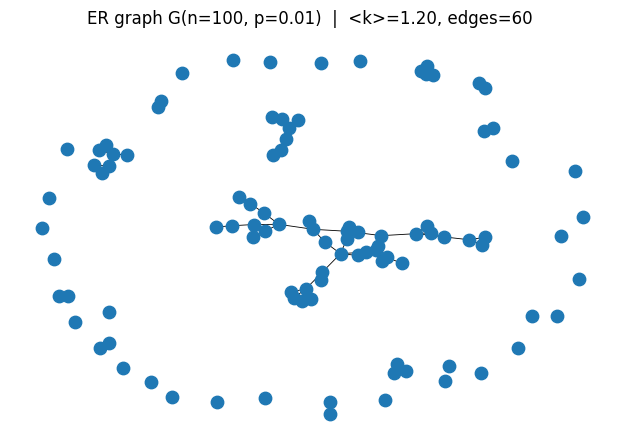

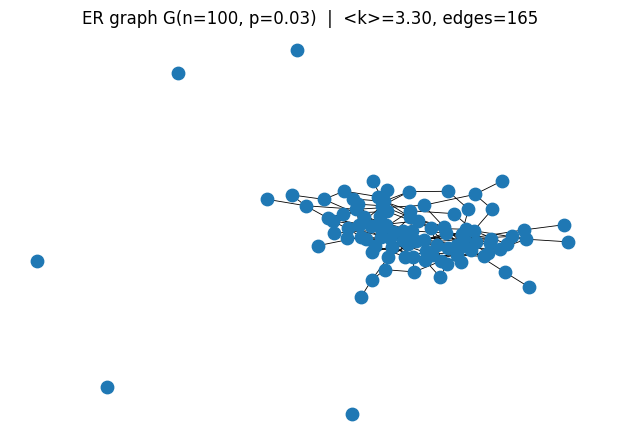

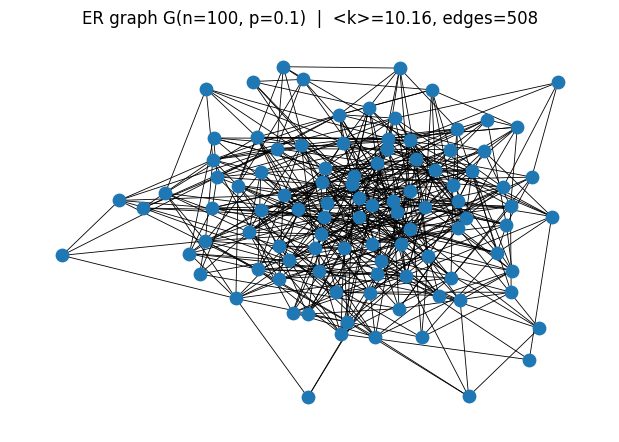

In [5]:
n = 100
p_list = [0.01, 0.03, 0.10]

for p in p_list:
    G = nx.erdos_renyi_graph(n, p, seed=1)
    stats = basic_stats(G)
    draw_graph(G, title=f"ER graph G(n={n}, p={p})  |  <k>={stats['k_mean']:.2f}, edges={stats['m']}")


## A2) Check \(\langle k \rangle \approx p(n-1)\)

### Task A2
For each `p`, compute:
- empirical mean degree \(\langle k \rangle\)
- predicted \(p(n-1)\)

They will not match perfectly (randomness), but should be close.


In [6]:
n = 200
p_list = [0.01, 0.02, 0.05]

for p in p_list:
    G = nx.erdos_renyi_graph(n, p, seed=2)
    stats = basic_stats(G)
    predicted = p * (n - 1)
    print(f"p={p:0.3f} | empirical <k>={stats['k_mean']:.3f} | predicted p(n-1)={predicted:.3f}")


p=0.010 | empirical <k>=2.050 | predicted p(n-1)=1.990
p=0.020 | empirical <k>=4.070 | predicted p(n-1)=3.980
p=0.050 | empirical <k>=9.960 | predicted p(n-1)=9.950


### Short answer (Part A)
Write 2–3 sentences:

1. What does `p` control in an ER graph?
2. What happens to the network as `p` increases?


**Your answers here:**

1.  
2.  


# Part B — Degree distribution (Binomial → Poisson idea)

For ER graphs:
- Degree distribution is binomial (exactly)
- In the limit of large \(n\), small \(p\), with fixed \(\lambda = \langle k \rangle\), it approaches a **Poisson** distribution

We will see this visually by:
1. plotting a degree histogram
2. overlaying a Poisson pmf with \(\lambda = \langle k \rangle\)


## B1) Degree histogram + Poisson overlay

### Task B1
Run this cell for `n=1000` and `p` chosen so that \(\langle k \rangle\approx 6\).

Hint: choose `p ≈ 6/(n-1)`.


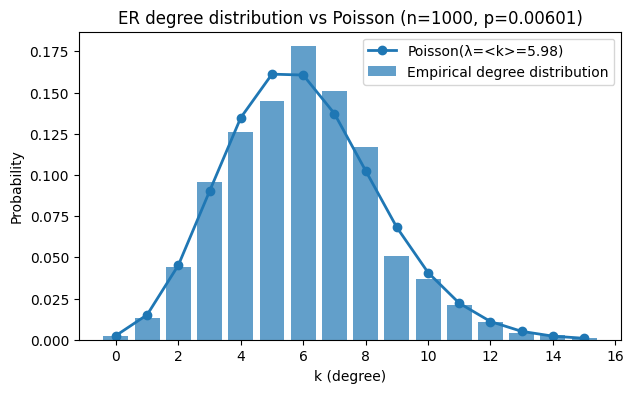

Empirical <k>: 5.98   Max degree: 15.0


In [7]:
n = 1000
k_target = 6
p = k_target / (n - 1)

G = nx.erdos_renyi_graph(n, p, seed=3)
stats = basic_stats(G)
k_vals, probs, degrees = degree_histogram_data(G)

lam = stats["k_mean"]
poiss = poisson_pmf(k_vals, lam)

plt.figure(figsize=(7,4))
plt.bar(k_vals, probs, alpha=0.7, label="Empirical degree distribution")
plt.plot(k_vals, poiss, marker="o", linewidth=2, label=f"Poisson(λ=<k>={lam:.2f})")
plt.xlabel("k (degree)")
plt.ylabel("Probability")
plt.title(f"ER degree distribution vs Poisson (n={n}, p={p:.5f})")
plt.legend()
plt.show()

print("Empirical <k>:", stats["k_mean"], "  Max degree:", stats["k_max"])


## B2) Few hubs in ER graphs

Random networks tend to have **no extreme outliers**:
- most degrees are close to \(\langle k \rangle\)
- the maximum degree is not dramatically larger than the mean

### Task B2
Run the cell and compare `k_max` to `<k>` for different sizes.


In [8]:
k_target = 6
for n in [200, 500, 1000, 2000]:
    p = k_target / (n - 1)
    G = nx.erdos_renyi_graph(n, p, seed=4)
    stats = basic_stats(G)
    ratio = stats["k_max"] / stats["k_mean"]
    print(f"n={n:4d}  <k>={stats['k_mean']:.2f}  k_max={stats['k_max']:.0f}  k_max/<k>={ratio:.2f}")


n= 200  <k>=6.08  k_max=13  k_max/<k>=2.14
n= 500  <k>=5.87  k_max=16  k_max/<k>=2.73
n=1000  <k>=6.02  k_max=15  k_max/<k>=2.49
n=2000  <k>=5.99  k_max=15  k_max/<k>=2.50


### Short answer (Part B)
Write 2–4 sentences:

1. Does the Poisson curve match the empirical histogram well? Why or why not?
2. Why do ER graphs have “few hubs” compared to many real networks?


**Your answers here:**

1.  
2.  


# Part C — Giant component / phase transition

A famous result for ER graphs:
- When \(\langle k \rangle < 1\): components are small (no giant component)
- Around \(\langle k \rangle \approx 1\): a **giant component** suddenly appears
- When \(\langle k \rangle > 1\): a large fraction of nodes are in the giant component

We will observe this by simulation.


## C1) Measure largest connected component size as p changes

### Task C1
- Fix `n=400`
- Sweep `p` values
- Compute `S = (size of largest component)/n`
- Plot `S` against `<k>`

**Hint:** we plot vs `<k>` because `<k>≈p(n-1)` is the key control parameter.


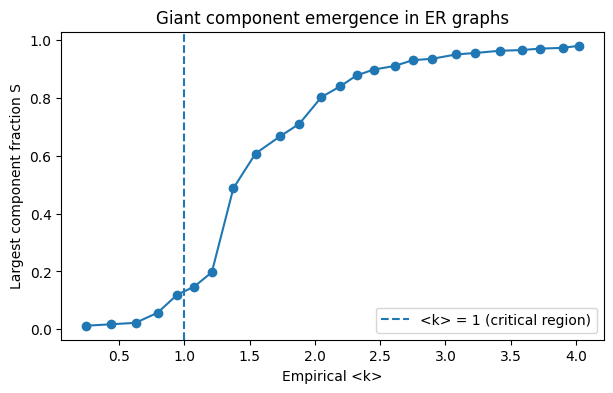

In [9]:
def largest_component_fraction(G):
    n = G.number_of_nodes()
    if n == 0:
        return 0.0
    comps = list(nx.connected_components(G))
    largest = max(len(c) for c in comps) if comps else 0
    return largest / n

n = 400
p_values = np.linspace(0.0005, 0.01, 25)  # adjust if needed

k_means = []
S_vals = []

for p in p_values:
    G = nx.erdos_renyi_graph(n, p, seed=10)
    stats = basic_stats(G)
    S = largest_component_fraction(G)
    k_means.append(stats["k_mean"])
    S_vals.append(S)

plt.figure(figsize=(7,4))
plt.plot(k_means, S_vals, marker="o")
plt.axvline(1.0, linestyle="--", label="<k> = 1 (critical region)")
plt.xlabel("Empirical <k>")
plt.ylabel("Largest component fraction S")
plt.title("Giant component emergence in ER graphs")
plt.legend()
plt.show()


### Task C1B (optional, but informative)
Because graphs are random, a single run is noisy. We can average over multiple trials.

Run this to smooth the curve.


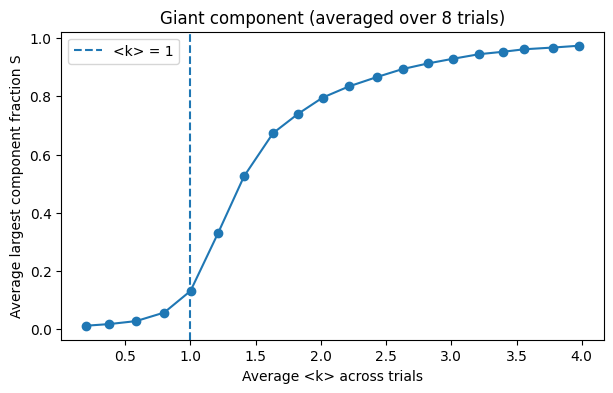

In [10]:
def average_giant_component(n, p, trials=10, base_seed=0):
    S_list = []
    k_list = []
    for t in range(trials):
        G = nx.erdos_renyi_graph(n, p, seed=base_seed+t)
        stats = basic_stats(G)
        S_list.append(largest_component_fraction(G))
        k_list.append(stats["k_mean"])
    return float(np.mean(k_list)), float(np.mean(S_list))

n = 400
p_values = np.linspace(0.0005, 0.01, 20)
trials = 8

k_means_avg = []
S_avg = []
for p in p_values:
    km, Sm = average_giant_component(n, p, trials=trials, base_seed=20)
    k_means_avg.append(km)
    S_avg.append(Sm)

plt.figure(figsize=(7,4))
plt.plot(k_means_avg, S_avg, marker="o")
plt.axvline(1.0, linestyle="--", label="<k> = 1")
plt.xlabel("Average <k> across trials")
plt.ylabel("Average largest component fraction S")
plt.title(f"Giant component (averaged over {trials} trials)")
plt.legend()
plt.show()


### Short answer (Part C)
Write 2–4 sentences:

1. Around what value of `<k>` does the giant component appear?
2. Why is this behaviour described as a “phase transition” (qualitatively)?


**Your answers here:**

1.  
2.  


# Part D — Small-world and clustering

Two common network measures:
- **Average shortest path length**: how many steps it takes (on average) to get from one node to another
- **Clustering coefficient**: how likely my neighbours are also connected to each other (triangles)

ER graphs typically have:
- **small average path length** (often grows like \(\log n\))
- **low clustering** (usually much smaller than real networks)

We will measure these and compare with a Watts–Strogatz (WS) small-world model.


## D1) Measure path length and clustering in ER graphs

### Task D1
Generate ER graphs for increasing `n` (keeping `<k>` ~ constant), and measure:
- average shortest path length (on the largest connected component)
- average clustering coefficient

**Note:** path length requires the graph to be connected. We handle this by taking the **largest connected component**.


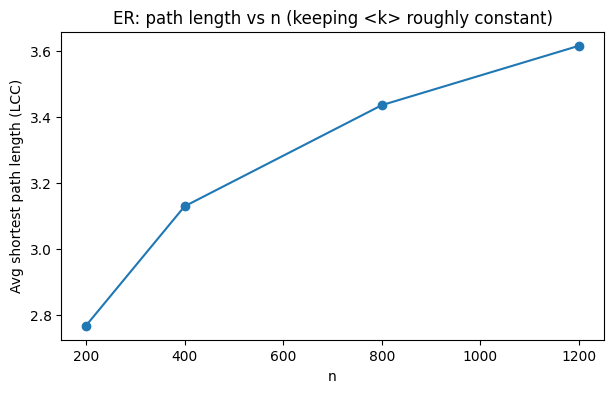

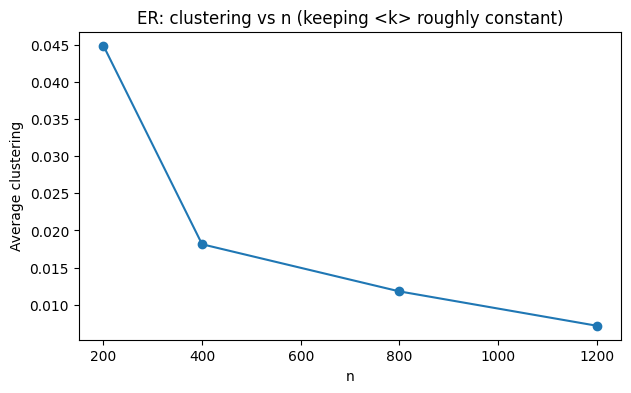

n= 200  <k>=7.99  path_len=2.769  clustering=0.0449
n= 400  <k>=7.80  path_len=3.129  clustering=0.0181
n= 800  <k>=8.07  path_len=3.435  clustering=0.0118
n=1200  <k>=8.18  path_len=3.614  clustering=0.0072


In [11]:
def average_path_length_lcc(G):
    # average shortest path length on Largest Connected Component
    if G.number_of_nodes() == 0:
        return float("nan")
    comps = list(nx.connected_components(G))
    if not comps:
        return float("nan")
    lcc_nodes = max(comps, key=len)
    H = G.subgraph(lcc_nodes).copy()
    if H.number_of_nodes() < 2:
        return float("nan")
    return nx.average_shortest_path_length(H)

k_target = 8
n_list = [200, 400, 800, 1200]

path_lengths = []
clusterings = []
k_means = []

for n in n_list:
    p = k_target / (n - 1)
    G = nx.erdos_renyi_graph(n, p, seed=99)
    stats = basic_stats(G)
    k_means.append(stats["k_mean"])
    clusterings.append(nx.average_clustering(G))
    path_lengths.append(average_path_length_lcc(G))

plt.figure(figsize=(7,4))
plt.plot(n_list, path_lengths, marker="o")
plt.xlabel("n")
plt.ylabel("Avg shortest path length (LCC)")
plt.title("ER: path length vs n (keeping <k> roughly constant)")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(n_list, clusterings, marker="o")
plt.xlabel("n")
plt.ylabel("Average clustering")
plt.title("ER: clustering vs n (keeping <k> roughly constant)")
plt.show()

for i, n in enumerate(n_list):
    print(f"n={n:4d}  <k>={k_means[i]:.2f}  path_len={path_lengths[i]:.3f}  clustering={clusterings[i]:.4f}")


## D2) Compare ER vs Watts–Strogatz (WS) small-world

WS model idea:
- Start with a **ring lattice** (high clustering, long paths)
- Rewire edges with probability `beta` (paths drop quickly, clustering stays relatively high for small beta)

### Task D2
Compare three networks of similar size/degree:
1. Ring lattice (`beta=0.0`)
2. Small-world (`beta=0.1`)
3. Very random (`beta=0.8`)

Measure path length and clustering for each.


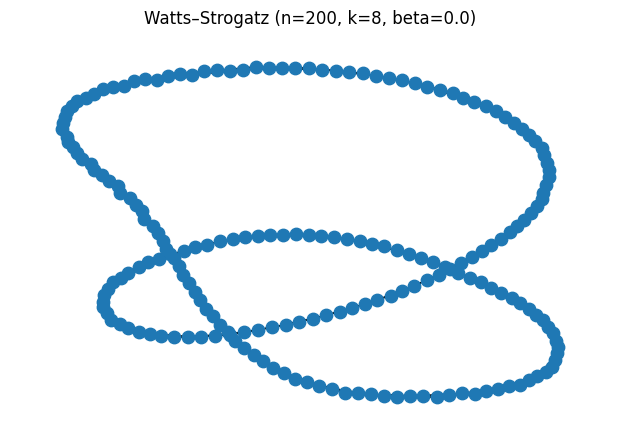

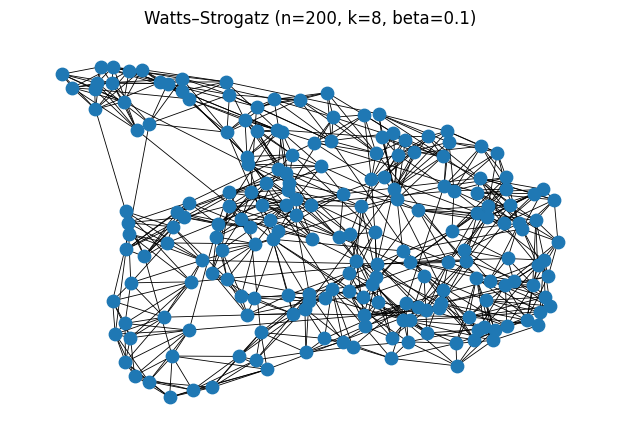

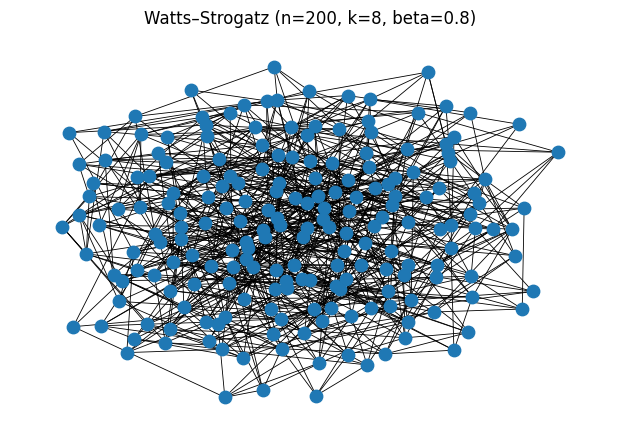

beta   clustering   path_length(LCC)
0.0     0.6429        12.940
0.1     0.4761        3.661
0.8     0.0465        2.761


In [12]:
n = 200
k = 8  # must be even for watts_strogatz_graph
betas = [0.0, 0.1, 0.8]

results = []

for beta in betas:
    H = nx.watts_strogatz_graph(n, k, beta, seed=7)
    cl = nx.average_clustering(H)
    pl = average_path_length_lcc(H)
    results.append((beta, cl, pl))

    draw_graph(H, title=f"Watts–Strogatz (n={n}, k={k}, beta={beta})", seed=2)

print("beta   clustering   path_length(LCC)")
for beta, cl, pl in results:
    print(f"{beta:0.1f}     {cl:0.4f}        {pl:0.3f}")


### Short answer (Part D)
Write 3–5 sentences:

1. How do ER graphs differ from WS graphs in terms of clustering and path length?
2. Why is the term “small-world” used?


**Your answers here:**

1.  
2.  


# Wrap-up reflection (5–10 min)

Answer briefly:

1. One thing ER graphs capture well about real networks.
2. One thing ER graphs fail to capture (compared to many real networks).
3. In one sentence: what did you learn about randomness and structure in networks?


**Your answers here:**

1.  
2.  
3.  


---
## Troubleshooting

- If plots do not appear in VS Code, try running in a browser Jupyter Notebook.
- If average path length gives an error, it may be because the graph is disconnected. We use the largest connected component to avoid this.
- If Poisson overlay looks imperfect: ER degree is binomial; Poisson is an approximation in a certain limit (large n, small p, fixed <k>).
